# Laya vs Logistic Regression: ticket type

**Question.** Can a pretrained model route IT tickets better than a simple baseline?

| | Baseline | Laya |
|---|---|---|
| Model | TF-IDF + Logistic Regression | ModernBERT-large, 421M parameters |
| How it reads | counts words | reads the whole ticket |
| Output | probability per type | probability per type, for one typed question |

- The baseline scored **79.95%** test accuracy. It is at its ceiling on this data.
- Links: [baseline notebook](../topic-classification/department_classifier_pipeline.ipynb), [Laya on Hugging Face](https://huggingface.co/convaiinnovations/laya).

**Models.** Same rows, same target (`type`), same input (`subject` + `body`).

| Model | What it is | Text |
|---|---|---|
| A | Logistic Regression, frozen (not retrained) | cleaned (the baseline's own) |
| B | Laya zero-shot | raw |
| C | Laya zero-shot | cleaned |
| D | Laya fine-tuned | raw or cleaned (decided in Phase 4) |

- **Zero-shot** means no training on our data.
- **Fine-tuned** means trained on our 11,670 training tickets.

**Rules, fixed before any Laya score:**
- Use validation only. The test set stays sealed until the end.
- Cleaning matters only if B and C differ by more than 1 point of accuracy.
- Write the question once. Never tune it on validation.
- Laya wins only if its test accuracy is more than 1 point above the baseline.

**Why:** rules set before the results cannot be bent to fit the results.

---
# Phase 1: Same rows as the baseline

## Step 1: Setup
Seed, constants and library versions.

In [1]:
# Step 1: imports, seed, constants
import sys
import time
from pathlib import Path

import joblib
import laya
import numpy as np
import pandas as pd
import sklearn
import torch
import transformers
from sklearn.metrics import accuracy_score, f1_score, recall_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

BASELINE_DIR = Path("../topic-classification")
RAW_FILE = BASELINE_DIR / "data" / "aa_dataset-tickets-multi-lang-5-2-50-version.csv"
SPLITS_FILE = BASELINE_DIR / "artifacts" / "splits.csv"            # written by the baseline's Phase 4B (export) step
BASELINE_MODEL = BASELINE_DIR / "artifacts" / "type_classifier.joblib"
PRED_DIR = Path("predictions")
PRED_DIR.mkdir(exist_ok=True)

MODEL_ID = "convaiinnovations/laya"
TYPES = np.array(["Incident", "Request", "Problem", "Change"])   # same order as the baseline
TIE_TOLERANCE = 0.01          # differences within 1 point of accuracy are noise (baseline rule)
ROUTE_THRESHOLD = 0.75        # the baseline's auto-routing line
TARGET_AUTO_ACCURACY = 0.95   # product target for tickets routed without a person
BASELINE_VAL = {"accuracy": 0.789632, "macro F1": 0.807491}   # baseline notebook, Phase 4B (confirm)

for lib in [np, pd, sklearn, torch, transformers, laya]:
    print(f"{lib.__name__:13s} {lib.__version__}")
print(f"{'python':13s} {sys.version.split()[0]}   ·   MPS available: {torch.backends.mps.is_available()}")

numpy         2.5.3
pandas        3.0.6
sklearn       1.9.1
torch         2.14.1
transformers  5.18.0
laya          0.3.28
python        3.12.15   ·   MPS available: True


## Step 2: Load the baseline's split and add the raw text
- **Decision:** read the split. Never recompute it.
- **Why:** the same rows in every model give a fair comparison.
- `text_raw` is `subject + body`, before cleaning.
- `text_clean` is the baseline's cleaned text. It removes formatting leftovers. It replaces emails, URLs and long numbers.
- A **family** is a group of reworded copies of one ticket. One family stays in one split. **Why:** copies in both train and test would leak the answers.
- Checks stop the notebook if the rows differ, or if one family sits in two splits.

In [2]:
# Step 2: tickets = baseline split + raw text; Seam 1 asserts stop here if the rows differ
df_raw = pd.read_csv(RAW_FILE)
splits = pd.read_csv(SPLITS_FILE)

tickets = splits.join(df_raw[["subject", "body", "type", "language"]], on="raw_row", rsuffix="_raw")
tickets["text_raw"] = (tickets["subject"].fillna("") + " " + tickets["body"].fillna("")).str.strip()

assert (tickets["type"] == tickets["type_raw"]).all(), "split file does not line up with the raw CSV"
assert (tickets["language"] == "en").all(), "split file holds non-English rows"
assert set(tickets["type"]) == set(TYPES)
for a, b in [("train", "validation"), ("train", "test"), ("validation", "test")]:
    fa, fb = (set(tickets.loc[tickets["split"] == s, "family_id"]) for s in (a, b))
    assert not fa & fb, f"a family appears in both {a} and {b}"
assert tickets["split"].value_counts().to_dict() == {"train": 11670, "validation": 2334, "test": 2334}
tickets = tickets[["raw_row", "family_id", "split", "type", "text_raw", "text_clean"]]
print("Same rows, same families, same split as the baseline ✓")

changed = tickets["text_raw"] != tickets["text_clean"]
print(f"Cleaning changed the text of {changed.sum():,} of {len(tickets):,} tickets ({changed.mean():.0%})\n")
example = tickets[changed & tickets["text_raw"].str.contains(r"\\n|<br|@|http", regex=True)].iloc[0]
print(f"raw:   {example['text_raw'][:300]}\nclean: {example['text_clean'][:300]}")
val = tickets[tickets["split"] == "validation"].reset_index(drop=True)

Same rows, same families, same split as the baseline ✓
Cleaning changed the text of 1,086 of 16,338 tickets (7%)

raw:   Account Disruption Dear Customer Support Team,\n\nI am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to account settings, leading to substantial inconvenience. I have attempted to log in m
clean: Account Disruption Dear Customer Support Team, I am writing to report a significant problem with the centralized account management portal, which currently appears to be offline. This outage is blocking access to account settings, leading to substantial inconvenience. I have attempted to log in mult


---
# Phase 2: One scoring step for every model

**How models are judged:**
- Accuracy decides.
- A gap within 1 point is a tie. The higher macro F1 wins the tie.
- Every type needs recall above 0.
- ECE and auto-routing are shown next to accuracy.

**Why:** a router acts on confidence, not only on the top answer.

| Term | Meaning |
|---|---|
| Accuracy | share of tickets with the right type |
| Macro F1 | average F1 over the 4 types. Small types count as much as big ones |
| Recall | share of one type's tickets that the model finds |
| ECE | gap between confidence and accuracy. Lower is better |
| Auto-routing | tickets sent without a person, when confidence is 0.75 or more |

Every model writes the same file. Columns: `raw_row, split, type, pred, conf, p_Incident ... p_Change`. One function scores all files.

In [3]:
# Phase 2: prediction file contract (Seam 2) and the one scoring function
P_COLS = [f"p_{t}" for t in TYPES]

def check_predictions(pred, rows):
    assert list(pred.columns[:5]) == ["raw_row", "split", "type", "pred", "conf"] and set(P_COLS) <= set(pred.columns)
    assert (pred["raw_row"].to_numpy() == rows["raw_row"].to_numpy()).all(), "prediction rows differ from the split rows"
    assert set(pred["pred"]) <= set(TYPES)
    assert np.allclose(pred[P_COLS].sum(axis=1), 1, atol=1e-3), "probabilities do not add up to 1"
    assert np.allclose(pred["conf"], pred[P_COLS].max(axis=1)) and (pred["pred"] == TYPES[pred[P_COLS].to_numpy().argmax(1)]).all()

def expected_calibration_error(conf, correct, bins=10):  # same as the baseline, Step 19
    bin_id = np.minimum((conf * bins).astype(int), bins - 1)
    return sum(abs(correct[bin_id == b].mean() - conf[bin_id == b].mean()) * (bin_id == b).mean()
               for b in range(bins) if (bin_id == b).any())

def score(pred):
    y, p, conf = pred["type"].to_numpy(), pred["pred"].to_numpy(), pred["conf"].to_numpy()
    correct = y == p
    recalls = recall_score(y, p, labels=TYPES, average=None, zero_division=0)
    thresholds = np.round(np.arange(0.40, 0.96, 0.05), 2)
    meets = [t for t in thresholds if (conf >= t).any() and correct[conf >= t].mean() >= TARGET_AUTO_ACCURACY]
    own = min(meets) if meets else np.nan
    return pd.Series({
        "accuracy": accuracy_score(y, p), "macro F1": f1_score(y, p, labels=TYPES, average="macro"),
        **{f"recall {t}": r for t, r in zip(TYPES, recalls)},
        "ECE": expected_calibration_error(conf, correct),
        f"auto-routed @{ROUTE_THRESHOLD}": (conf >= ROUTE_THRESHOLD).mean(),
        f"accuracy @{ROUTE_THRESHOLD}": correct[conf >= ROUTE_THRESHOLD].mean() if (conf >= ROUTE_THRESHOLD).any() else np.nan,
        f"own line for {TARGET_AUTO_ACCURACY:.0%}": own,
        "auto-routed @own line": (conf >= own).mean() if meets else 0.0,
    })

def save_predictions(arm, rows, proba):
    proba = np.asarray(proba)
    pred = pd.DataFrame({"raw_row": rows["raw_row"], "split": rows["split"], "type": rows["type"],
                         "pred": TYPES[proba.argmax(1)], "conf": proba.max(1)})
    pred[P_COLS] = proba
    check_predictions(pred, rows)
    pred.to_csv(PRED_DIR / f"{arm}_{rows['split'].iloc[0]}.csv", index=False)
    return pred

## Model A: the baseline, rebuilt from its saved model
- The saved model trained on training rows only.
- Its validation score must equal the baseline notebook's score.
- **Check:** if the numbers match, the scoring step is correct.
- **Why:** a wrong scorer would make every later comparison wrong.

In [4]:
# Model A: baseline on validation; must reproduce the baseline notebook's numbers
lr = joblib.load(BASELINE_MODEL)
t0 = time.perf_counter()
proba_a = pd.DataFrame(lr.predict_proba(val["text_clean"]), columns=lr.classes_)[TYPES]
sec_per_ticket = {"A · Logistic Regression": (time.perf_counter() - t0) / len(val)}
pred_a = save_predictions("arm_a_lr", val, proba_a)
score_a = score(pred_a)

for k, v in BASELINE_VAL.items():
    assert abs(score_a[k] - v) < 5e-4, f"{k}: {score_a[k]:.6f} here vs {v} in the baseline notebook"
print(f"Scoring check ✓: accuracy {score_a['accuracy']:.4f}, macro F1 {score_a['macro F1']:.4f} (baseline notebook: "
      f"{BASELINE_VAL['accuracy']:.4f}, {BASELINE_VAL['macro F1']:.4f})")

Scoring check ✓: accuracy 0.7896, macro F1 0.8075 (baseline notebook: 0.7896, 0.8075)


---
# Phase 3: Laya zero-shot

**The question.** Laya answers one typed question for each ticket. It gives a probability for each of the 4 types.
- Written once, from the usual IT-service meaning of each type.
- Never tuned on validation.
- **Why:** tuning the wording on validation would leak validation into the design.

In [5]:
# Phase 3: the one typed question Laya answers, and the batch predictor
TYPE_QUESTION = {"ticket_type": {"type": "choice",
    "instructions": "What type of IT support ticket is this?",
    "criteria": {
        "Incident": "something is broken, down or not working right now and needs a fix",
        "Request":  "asks for information, access, help or a standard service; nothing is broken",
        "Problem":  "a recurring or underlying cause behind repeated failures that needs investigation",
        "Change":   "asks to add, upgrade, modify or improve a system, feature or configuration"}}}

agent = laya.load(MODEL_ID)
n_params = sum(p.numel() for p in agent.model.parameters())
print(f"{MODEL_ID}: {n_params / 1e6:,.0f}M parameters on {agent.device}")

def predict_laya(texts, batch_size=32):
    # batches of 5+ rows run in fp16 on MPS: probabilities differ from single calls by < 0.001, the answer does not change
    out = agent.predict_batch(list(texts), TYPE_QUESTION, batch_size=batch_size, sort_by_length=True)
    proba = [[r["answers"]["ticket_type"]["probabilities"][t] for t in TYPES] for r in out]
    truncated = np.array([r["usage"]["truncated"] for r in out])
    return np.array(proba), truncated

convaiinnovations/laya: 421M parameters on mps


## Smoke test: 50 validation tickets
**Why:** a small run finds errors in minutes, before the full run.

In [6]:
# Smoke test: the run completes and the prediction file passes the contract
smoke = val.head(50)
proba, _ = predict_laya(smoke["text_raw"])
save_predictions("smoke", smoke, proba)
(PRED_DIR / "smoke_validation.csv").unlink()
print("Smoke test ✓: 50 tickets predicted, prediction file valid")

Smoke test ✓: 50 tickets predicted, prediction file valid


## Models B and C: Laya zero-shot on raw and on cleaned text
Same model, same question. Only the text changes.

In [7]:
# Models B and C: same model, same question; only the text differs
preds = {"A · Logistic Regression": pred_a}
for arm, name, col in [("arm_b_zeroshot_raw", "B · Laya zero-shot, raw", "text_raw"),
                       ("arm_c_zeroshot_clean", "C · Laya zero-shot, cleaned", "text_clean")]:
    t0 = time.perf_counter()
    proba, truncated = predict_laya(val[col])
    sec_per_ticket[name] = (time.perf_counter() - t0) / len(val)
    preds[name] = save_predictions(arm, val, proba)
    print(f"{name}: {len(val):,} tickets in {sec_per_ticket[name] * len(val) / 60:.1f} min · "
          f"cut at 512 tokens: {truncated.sum():,}")

B · Laya zero-shot, raw: 2,334 tickets in 3.3 min · cut at 512 tokens: 0


C · Laya zero-shot, cleaned: 2,334 tickets in 3.9 min · cut at 512 tokens: 0


---
# Phase 4: Compare on validation

In [8]:
# Phase 4: one table, every model scored by the same function
comparison = pd.DataFrame({name: score(p) for name, p in preds.items()}).T
comparison["seconds / ticket"] = pd.Series(sec_per_ticket)
comparison["model size"] = ["%.1f MB" % (BASELINE_MODEL.stat().st_size / 1e6)] + [f"{n_params / 1e6:,.0f}M params"] * 2
comparison.round(3)

,accuracy,macro F1,recall Incident,recall Request,recall Problem,recall Change,ECE,auto-routed @0.75,accuracy @0.75,own line for 95%,auto-routed @own line,seconds / ticket,model size
A · Logistic Regression,0.790,0.807,0.712,0.991,0.577,0.959,0.045,0.485,0.956,0.75,0.485,0.000,2.6 MB
"B · Laya zero-shot, raw",0.792,0.784,0.878,0.943,0.332,0.963,0.133,0.293,0.994,0.65,0.424,0.085,421M params
"C · Laya zero-shot, cleaned",0.789,0.783,0.870,0.943,0.334,0.963,0.131,0.292,0.994,0.65,0.421,0.100,421M params


In [9]:
# Phase 4 (cleaning verdict): does the cleaned text change Laya's answers?
b, c = preds["B · Laya zero-shot, raw"], preds["C · Laya zero-shot, cleaned"]
gap = comparison.loc["C · Laya zero-shot, cleaned", "accuracy"] - comparison.loc["B · Laya zero-shot, raw", "accuracy"]
print(f"Same answer on raw and cleaned text: {(b['pred'] == c['pred']).mean():.1%} of tickets")
print(f"Accuracy, cleaned minus raw: {gap * 100:+.2f} points (noise band ±{TIE_TOLERANCE * 100:.0f})")
print("Verdict: cleaning " + ("MATTERS: Model D trains on cleaned text" if gap > TIE_TOLERANCE
      else "does NOT matter: Model D trains on raw text (nothing to build around the model)" if gap >= -TIE_TOLERANCE
      else "HURTS: Model D trains on raw text"))

Same answer on raw and cleaned text: 99.7% of tickets
Accuracy, cleaned minus raw: -0.26 points (noise band ±1)
Verdict: cleaning does NOT matter: Model D trains on raw text (nothing to build around the model)


In [10]:
# Phase 4 (where): confusion of the better zero-shot model, rows = true type, % of each row
from sklearn.metrics import confusion_matrix
best_zs = comparison.iloc[1:3]["accuracy"].idxmax()
pd.DataFrame(confusion_matrix(preds[best_zs]["type"], preds[best_zs]["pred"], labels=TYPES, normalize="true") * 100,
             index=TYPES, columns=TYPES).round(1).rename_axis(best_zs)

,Incident,Request,Problem,Change
"B · Laya zero-shot, raw",,,,
Incident,87.8,0.2,12.0,0.0
Request,4.8,94.3,0.2,0.8
Problem,66.6,0.2,33.2,0.0
Change,2.9,0.8,0.0,96.3


**Zero-shot result (validation).** Model B ties the baseline with no training.

| | A baseline | B Laya zero-shot |
|---|---|---|
| Accuracy | 79.0% | 79.2% |
| Incident recall | 71% | 88% |
| Problem recall | 58% | 33% |
| Macro F1 | 0.81 | 0.78 |
| Tickets with confidence 0.75 or more | 49% | 29% |
| Accuracy on those tickets | 95.6% | 99.4% |
| ECE | 0.05 | 0.13 |

- The accuracy gap is 0.2 points. It is inside the 1-point noise band: a tie.
- Laya calls 2 of 3 Problem tickets Incident. The baseline found the same blurred line in the labels.
- Laya's confidence is less honest. The checkpoint warns that some of its temperatures are invalid.
- No ticket exceeds Laya's 512-token limit.

### Decision: Model D trains on raw text
- Cleaning changes the answer on 0.3% of tickets.
- Accuracy moves by -0.26 points. That is inside the noise.
- **Why raw:** Laya reads raw text well. Nothing else needs to be built around it.

**What fine-tuning must show:**
- Learn the dataset's own Incident / Problem line.
- Make the confidence honest.
- Beat the baseline by more than 1 point.
- Cost: about 0.16 s per ticket on a laptop GPU. The baseline costs about 0 s.

---
# Phase 5: Model D, Laya fine-tuned on the training rows

Training runs outside this notebook, in `train_arm_d.py`. It is Laya's official Apple-Silicon script. Its header lists every change. This notebook reads the results: one prediction file per epoch, scored on validation with the same `score()`.

**How the training settings were chosen** (logs in `logs/`):

| Problem | What we tried | Result | Why it worked |
|---|---|---|---|
| Loss rose from 0.96 to 2.51 in about 12 updates. Random guessing among 4 types scores 1.39 | Script defaults | Failed | n/a |
| | Add **linear warmup** over the first 10% of updates | Better, but still diverged at about 1,400 tickets | Small first steps keep the weights from jumping |
| Still diverged | 3 runs, one change each, stopped at 2,400 tickets. Pass rule written first | No gradient checkpointing: failed. Learning rate x 0.3: failed. **Cross-entropy only: passed** | Laya's RL term made training unstable on our data |

**Final settings:**

| Setting | Value |
|---|---|
| Seed | 42 |
| Optimizer | AdamW |
| Learning rate | 2.5e-5 encoder, 1e-4 head |
| Schedule | warmup 146 updates, then cosine decay to 1e-6 |
| Batch | 2 tickets x 16 accumulated = 32 per update |
| Length | 4 epochs = 1,460 updates (1 epoch = one pass over the training tickets) |
| Precision | fp32 on the Mac GPU (MPS) |
| Input | raw text, Model B's exact question |

In [11]:
# Phase 5 (load): per-epoch validation predictions from the seed-42 run, plus the run log
import json, re
import train_arm_d
assert train_arm_d.TYPE_QUESTION == TYPE_QUESTION, "Model D must be trained on Model B's exact question"

SEED = 42
log_lines = [l for l in Path(f"logs/arm_d_seed{SEED}.log").read_text().splitlines() if "EPOCH" in l]
epoch_log = pd.DataFrame([{"epoch": int(m[1]), "train hours": float(m[2]), "train loss": float(m[3])}
                          for m in (re.search(r"EPOCH (\d+) done · ([\d.]+) h · \d+ updates · avg loss ([\d.]+)", l) for l in log_lines)]).set_index("epoch")

epoch_preds = {}
for e in epoch_log.index:
    p = pd.read_csv(PRED_DIR / f"arm_d_seed{SEED}_epoch{e}_validation.csv")
    check_predictions(p, val)
    epoch_preds[e] = p
curve = pd.concat([epoch_log, pd.DataFrame({e: score(p) for e, p in epoch_preds.items()}).T], axis=1)
curve[["train hours", "train loss", "accuracy", "macro F1", "recall Incident", "recall Problem", "ECE",
       f"auto-routed @{ROUTE_THRESHOLD}", f"accuracy @{ROUTE_THRESHOLD}"]].round(3)

,train hours,train loss,accuracy,macro F1,recall Incident,recall Problem,ECE,auto-routed @0.75,accuracy @0.75
1,2.16,0.365,0.764,0.798,0.592,0.674,0.098,0.723,0.858
2,2.08,0.216,0.784,0.809,0.686,0.584,0.123,0.856,0.825
3,2.13,0.056,0.799,0.810,0.774,0.485,0.178,0.965,0.809
4,2.41,0.003,0.796,0.809,0.770,0.480,0.189,0.979,0.804


- Training loss falls to about 0.003. The model nearly memorizes the training tickets.
- Validation accuracy levels off after epoch 3.
- Confidence gets less honest each epoch (ECE 0.10 to 0.19).
- By epoch 4 the model is 75% sure or more on 98% of tickets. It is right on 80% of them.

In [12]:
# Phase 5 (choose): the rule fixed before training: accuracy decides; within 1 point = tie → higher macro F1
best_acc = curve["accuracy"].max()
tied = curve[curve["accuracy"] >= best_acc - TIE_TOLERANCE]
CHOSEN_EPOCH = int(tied["macro F1"].idxmax())
print(f"Tied within 1 point of the best accuracy: epochs {list(tied.index)} → chosen: epoch {CHOSEN_EPOCH} "
      f"(macro F1 {tied.loc[CHOSEN_EPOCH, 'macro F1']:.4f})")

Tied within 1 point of the best accuracy: epochs [3, 4] → chosen: epoch 3 (macro F1 0.8097)


## Calibrate the chosen epoch on validation

**What:** temperature scaling. One number T divides the model's raw scores.
- T above 1 lowers confidence.
- The answer never changes.

**Keep rule (the baseline's):** keep T only if ECE falls and log-loss does not rise.

**How we test it:** out of fold.
- 5 folds, grouped by family.
- Each fold's T is scored on tickets it did not see.
- **Why:** scoring on the tickets that set T hides overfitting.

**Fit on raw logits, not on saved probabilities:**
- Laya rounds probabilities to 4 decimals.
- On epoch 3, half of the validation tickets read exactly 1.0000.
- A T fitted on those hit the 5.0 cap.
- We collect logits with Laya's own `laya.calibrate.records_from_labeled`. They reproduce every saved answer.

In [13]:
# Phase 5 (calibrate): temperature on raw logits; out-of-fold check; final T fitted on all validation
from sklearn.metrics import log_loss
from sklearn.model_selection import GroupKFold

logits = np.load(PRED_DIR / f"arm_d_seed{SEED}_epoch{CHOSEN_EPOCH}_validation_logits.npy")
y_val = val["type"].map({t: i for i, t in enumerate(TYPES)}).to_numpy()
assert (TYPES[logits.argmax(1)] == epoch_preds[CHOSEN_EPOCH]["pred"]).all(), "logits do not match the saved predictions"

def softmax_t(z, t):
    z = z / t - (z / t).max(1, keepdims=True)
    return np.exp(z) / np.exp(z).sum(1, keepdims=True)

def fit_temperature(z, y):  # same objective as Laya's fit_temperature: minimise log-loss over log T
    zt, yt = torch.tensor(z, dtype=torch.float64), torch.tensor(y)
    log_t = torch.zeros(1, dtype=torch.float64, requires_grad=True)
    opt = torch.optim.LBFGS([log_t], lr=0.1, max_iter=500)
    def closure():
        opt.zero_grad()
        loss = torch.nn.functional.cross_entropy(zt / log_t.exp(), yt)
        loss.backward()
        return loss
    opt.step(closure)
    return float(log_t.exp().clamp(0.5, 5.0))  # Laya serves temperatures in [0.5, 5]

oof = np.zeros_like(logits)
fold_t = []
for tr, te in GroupKFold(5).split(logits, y_val, val["family_id"]):
    fold_t.append(fit_temperature(logits[tr], y_val[tr]))
    oof[te] = softmax_t(logits[te], fold_t[-1])
raw = softmax_t(logits, 1.0)
calib = pd.DataFrame({name: {"log-loss": log_loss(y_val, p, labels=range(4)),
                             "ECE": expected_calibration_error(p.max(1), TYPES[p.argmax(1)] == val["type"].to_numpy())}
                      for name, p in {"raw": raw, "temperature (out of fold)": oof}.items()}).T
KEEP_T = calib.loc["temperature (out of fold)", "ECE"] < calib.loc["raw", "ECE"] and \
         calib.loc["temperature (out of fold)", "log-loss"] <= calib.loc["raw", "log-loss"]
TEMPERATURE = fit_temperature(logits, y_val) if KEEP_T else 1.0
print(f"Fold temperatures: {[round(t, 2) for t in fold_t]} → final T = {TEMPERATURE:.3f} · keep: {KEEP_T}")

chosen_dir = Path(f"checkpoints/seed{SEED}/chosen_epoch{CHOSEN_EPOCH}_calibrated")
served_t = json.loads((chosen_dir / "rl_agent_config.json").read_text())["temperature"][0]
assert abs(served_t - TEMPERATURE) < 1e-3, f"saved checkpoint serves T={served_t}, notebook fitted {TEMPERATURE}"
calib.round(4)

Fold temperatures: [3.63, 3.35, 3.57, 3.53, 3.46] → final T = 3.509 · keep: True


,log-loss,ECE
raw,1.2168,0.1784
temperature (out of fold),0.5294,0.0759


In [14]:
# Phase 5 (compare): every model on validation, same score(); Model D calibrated = softmax(logits / T)
pred_d = save_predictions(f"arm_d_seed{SEED}_calibrated", val, softmax_t(logits, TEMPERATURE))
preds[f"D · Laya fine-tuned, epoch {CHOSEN_EPOCH}, raw"] = epoch_preds[CHOSEN_EPOCH]
preds[f"D · Laya fine-tuned, epoch {CHOSEN_EPOCH}, calibrated"] = pred_d
final = pd.DataFrame({name: score(p) for name, p in preds.items()}).T
final.round(3)

,accuracy,macro F1,recall Incident,recall Request,recall Problem,recall Change,ECE,auto-routed @0.75,accuracy @0.75,own line for 95%,auto-routed @own line
A · Logistic Regression,0.790,0.807,0.712,0.991,0.577,0.959,0.045,0.485,0.956,0.75,0.485
"B · Laya zero-shot, raw",0.792,0.784,0.878,0.943,0.332,0.963,0.133,0.293,0.994,0.65,0.424
"C · Laya zero-shot, cleaned",0.789,0.783,0.870,0.943,0.334,0.963,0.131,0.292,0.994,0.65,0.421
"D · Laya fine-tuned, epoch 3, raw",0.799,0.810,0.774,0.994,0.485,0.984,0.178,0.965,0.809,NaN,0.000
"D · Laya fine-tuned, epoch 3, calibrated",0.799,0.810,0.774,0.994,0.485,0.984,0.082,0.807,0.858,0.90,0.480


**Calibration result (seed 42).**

| | Raw | Calibrated (out of fold) |
|---|---|---|
| ECE | 0.178 | 0.076 |
| Log-loss | 1.22 | 0.53 |

- Accuracy stays 79.9%.
- T = 3.51. All 5 folds gave 3.35 to 3.63.
- The table above shows ECE 0.082. There, T is scored on the tickets that set it. Quote the out-of-fold 0.076.
- Calibrated Model D needs a 0.90 confidence line to route at 95% accuracy. It then routes about 48% of tickets. The baseline does the same at its 0.75 line.
- The 0.90 line was chosen on validation. It is a logged selection step.

### Where Model D stands (validation, seed 42 only)
- Accuracy 79.9% against 79.0%: +0.9 points. Inside the noise band: **a tie so far**.
- Problem recall went from 0.33 (zero-shot) to 0.48. The baseline has 0.58.
- ECE is 0.076. The baseline has 0.045.
- **Next:** seed 43 (Phase 6). Then open the test set once.

## Phase 6: Seed 43, then the sealed test set

**Seed 43.** Same settings as seed 42. Only the shuffle order and the head's starting values change.
- **Why a second seed:** one run cannot show if a result is real or luck.
- **Epoch rule:** same as before. Accuracy decides. A tie goes to the higher macro F1.

**Test set.** `score_test.py` scored it once for Model A, Model B and Model D.
- Model D: seed 42 epoch 3 and seed 43 epoch 2, each raw and calibrated.
- The script refuses to run again if any `predictions/*_test.csv` file exists.

**Seed 44 was not run.** **Why:** another seed after the test set is open would be a second look at the test set.

In [4]:
# Phase 6 (seed 43): epoch choice by the same rule, from the per-epoch validation files
import re
log43 = [l for l in Path("logs/arm_d_seed43.log").read_text().splitlines() if "EPOCH" in l]
loss43 = {int(m[1]): float(m[2]) for m in (re.search(r"EPOCH (\d+) done .* avg loss ([\d.]+)", l) for l in log43)}
val43 = {e: pd.read_csv(PRED_DIR / f"arm_d_seed43_epoch{e}_validation.csv") for e in loss43}
for p in val43.values():
    check_predictions(p, val)
curve43 = pd.DataFrame({e: score(p) for e, p in val43.items()}).T
curve43.insert(0, "train loss", pd.Series(loss43))
tied43 = curve43[curve43["accuracy"] >= curve43["accuracy"].max() - TIE_TOLERANCE]
CHOSEN_43 = int(tied43["macro F1"].idxmax())
print(f"Seed 43: tied within 1 point: epochs {list(tied43.index)} → chosen: epoch {CHOSEN_43}")
curve43[["train loss", "accuracy", "macro F1", "recall Problem", "ECE"]].round(3)

Seed 43: tied within 1 point: epochs [1, 2, 3, 4] → chosen: epoch 2


,train loss,accuracy,macro F1,recall Problem,ECE
1,0.367,0.801,0.795,0.351,0.032
2,0.205,0.796,0.816,0.561,0.119
3,0.056,0.793,0.804,0.456,0.181
4,0.007,0.793,0.805,0.460,0.193


- Seed 43 peaks at epoch 1 (80.1%).
- All four epochs are within 1 point: a tie.
- The tie-break picks epoch 2 (macro F1 0.816).
- Training loss again falls to about 0.007. Validation stays at 79 to 80%.
- The model memorizes the training tickets after one epoch.

In [5]:
# Phase 6 (test): every model on the test set, same score(); the test files were written once by score_test.py
test_rows = tickets[tickets["split"] == "test"].reset_index(drop=True)
TEST_FILES = {
    "A · Logistic Regression":                 "arm_a_lr",
    "B · Laya zero-shot, raw":                 "arm_b_zeroshot_raw",
    "D seed 42 · epoch 3, raw":                "arm_d_seed42_epoch3_raw",
    "D seed 42 · epoch 3, calibrated":         "arm_d_seed42_calibrated",
    f"D seed 43 · epoch {CHOSEN_43}, raw":        f"arm_d_seed43_epoch{CHOSEN_43}_raw",
    f"D seed 43 · epoch {CHOSEN_43}, calibrated": "arm_d_seed43_calibrated",
}
test_preds = {}
for name, stem in TEST_FILES.items():
    p = pd.read_csv(PRED_DIR / f"{stem}_test.csv")
    check_predictions(p, test_rows)
    test_preds[name] = p
test_table = pd.DataFrame({n: score(p) for n, p in test_preds.items()}).T
assert abs(test_table.loc["A · Logistic Regression", "accuracy"] - 0.7995) < 5e-4, "Model A must reproduce the baseline's test accuracy"
test_table[["accuracy", "macro F1", "recall Incident", "recall Problem", "ECE",
            f"auto-routed @{ROUTE_THRESHOLD}", f"accuracy @{ROUTE_THRESHOLD}"]].round(3)

,accuracy,macro F1,recall Incident,recall Problem,ECE,auto-routed @0.75,accuracy @0.75
A · Logistic Regression,0.799,0.815,0.729,0.597,0.063,0.461,0.964
"B · Laya zero-shot, raw",0.784,0.787,0.858,0.383,0.138,0.260,0.992
"D seed 42 · epoch 3, raw",0.817,0.827,0.800,0.516,0.159,0.961,0.828
"D seed 42 · epoch 3, calibrated",0.817,0.827,0.800,0.516,0.064,0.820,0.872
"D seed 43 · epoch 2, raw",0.797,0.818,0.709,0.609,0.120,0.871,0.837
"D seed 43 · epoch 2, calibrated",0.797,0.818,0.709,0.609,0.046,0.711,0.892


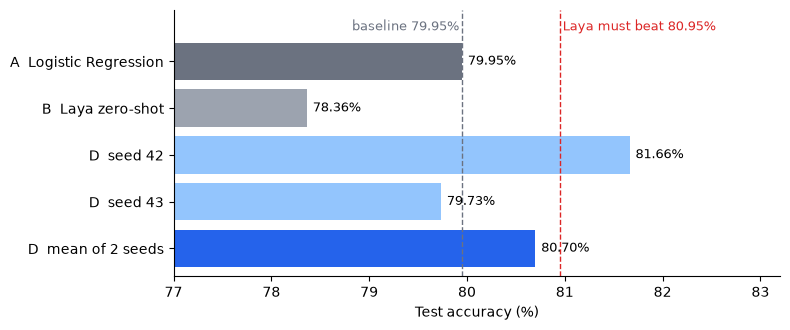

In [6]:
# Phase 6 (chart): test accuracy per model, with the baseline and the win line
import matplotlib.pyplot as plt

bars = {"A  Logistic Regression": test_table.loc["A · Logistic Regression", "accuracy"],
        "B  Laya zero-shot": test_table.loc["B · Laya zero-shot, raw", "accuracy"],
        "D  seed 42": test_table.loc["D seed 42 · epoch 3, raw", "accuracy"],
        f"D  seed 43": test_table.loc[f"D seed 43 · epoch {CHOSEN_43}, raw", "accuracy"]}
bars["D  mean of 2 seeds"] = (bars["D  seed 42"] + bars["D  seed 43"]) / 2
names, vals = list(bars), [v * 100 for v in bars.values()]
base = vals[0]

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh(names[::-1], vals[::-1], color=["#2563eb", "#93c5fd", "#93c5fd", "#9ca3af", "#6b7280"])
ax.axvline(base, color="#6b7280", ls="--", lw=1)
ax.axvline(base + 1, color="#dc2626", ls="--", lw=1)
ax.text(base + 1.03, 4.75, f"Laya must beat {base + 1:.2f}%", color="#dc2626", fontsize=9, va="center")
ax.text(base - 0.03, 4.75, f"baseline {base:.2f}%", color="#6b7280", fontsize=9, va="center", ha="right")
for y, v in enumerate(vals[::-1]):
    ax.text(v + 0.06, y, f"{v:.2f}%", va="center", fontsize=9)
ax.set_xlim(77, 83.2)
ax.set_ylim(-0.6, 5.1)
ax.set_xlabel("Test accuracy (%)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [6]:
# Phase 6 (decision): the rule fixed before training: Laya wins only if its accuracy beats the baseline's by MORE than 1 point
acc_a = test_table.loc["A · Logistic Regression", "accuracy"]
seed_acc = {s: test_table.loc[n, "accuracy"] for s, n in [(42, "D seed 42 · epoch 3, raw"), (43, f"D seed 43 · epoch {CHOSEN_43}, raw")]}
mean_d = np.mean(list(seed_acc.values()))
line = acc_a + TIE_TOLERANCE
print(f"Baseline {acc_a:.2%} → Laya must exceed {line:.2%}")
print(f"Seed 42 {seed_acc[42]:.2%} · seed 43 {seed_acc[43]:.2%} · mean {mean_d:.2%} · spread {abs(seed_acc[42] - seed_acc[43]) * 100:.1f} points")
print("VERDICT:", "Laya wins" if mean_d > line else "no win: the mean is not more than 1 point above the baseline (tie)")

Baseline 79.95% → Laya must exceed 80.95%
Seed 42 81.66% · seed 43 79.73% · mean 80.70% · spread 1.9 points
VERDICT: no win: the mean is not more than 1 point above the baseline (tie)


### Conclusion (test set, 2 seeds)
**Fine-tuned Laya does not clearly beat the baseline.**
- Mean of 2 seeds: 80.70%. Baseline: 79.95%. Gain: +0.75 points.
- Needed: more than 1 point. Result: a tie.
- Seed 42 alone: 81.66%. Seed 43: 79.73%.
- **Why we report the mean:** we planned the mean before the test. Picking the best seed afterward is cherry-picking.
- The seeds differ by 1.9 points on test and by 0.3 on validation. Test sampling noise (about 0.8 points at 2,334 tickets) is larger than seed noise.

| | Baseline (A) | Fine-tuned Laya (D, mean of 2) |
|---|---|---|
| Accuracy | 79.95% | 80.70% (seeds: 79.73 and 81.66) |
| Problem recall | 0.597 | 0.563 (0.517 and 0.609) |
| ECE, calibrated | 0.063 | 0.064 and 0.046 |
| At the 0.75 line: share routed | 46% | 71% and 82% |
| At the 0.75 line: accuracy on routed | 96.4% | 89% and 87% |
| Cost | seconds to train | about 8 h per seed on the Mac. About 0.1 s per ticket to score |

- Zero-shot Laya (B) is below the baseline on accuracy (78.36%), macro F1 and Problem recall.
- Fine-tuning closes the gap. It may add a little.
- Label noise is not the cause (Phase 7). The text alone may not decide Incident vs Problem.
- The extra gain is not worth the cost.
- Seed 44 was not run. A second look at the test set would break the "opened once" rule.

---
# Phase 7: Why does every model stop near 80%?

**Hypothesis to test:** the labels are noisy, so no model can do better.

**Checks** (train and validation rows only; the test set is not used):
1. Do reworded copies of one ticket keep the same label?
2. Do similar tickets from different families share a label?
3. Do the other columns (tags, queue, priority) add information beyond the text?

In [3]:
# Phase 7 (check 1): do reworded copies of one ticket keep the same label?
from IPython.display import display
dev = tickets[tickets["split"] != "test"].reset_index(drop=True)   # the test set stays sealed
multi = dev[dev.groupby("family_id")["type"].transform("size") >= 2].copy()
types_per_family = multi.groupby("family_id")["type"].nunique()
majority = multi.groupby("family_id")["type"].agg(lambda x: x.value_counts().index[0])
multi["agrees"] = multi["type"].to_numpy() == multi["family_id"].map(majority).to_numpy()
display(pd.Series({
    "families with 2+ tickets": types_per_family.size,
    "tickets in those families": len(multi),
    "families with 2+ different types": int((types_per_family > 1).sum()),
    "share of families that conflict": f"{(types_per_family > 1).mean():.1%}",
    "tickets matching their family's majority label": f"{multi['agrees'].mean():.1%}",
}, name="value").to_frame())
display((1 - multi.groupby("type")["agrees"].mean()).round(3).rename("share outvoted by its family").to_frame())

,value
families with 2+ tickets,3692
tickets in those families,10816
families with 2+ different types,59
share of families that conflict,1.6%
tickets matching their family's majority label,98.7%


,share outvoted by its family
type,
Change,0.016
Incident,0.012
Problem,0.031
Request,0.003


In [4]:
# Phase 7 (check 2): nearest ticket from ANOTHER family, same label?
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors
X = TfidfVectorizer(min_df=2, sublinear_tf=True).fit_transform(dev["text_clean"].fillna(""))
dist, idx = NearestNeighbors(n_neighbors=30, metric="cosine").fit(X).kneighbors(X)
fam, typ = dev["family_id"].to_numpy(), dev["type"].to_numpy()
nb_i, nb_d = np.zeros(len(dev), int), np.zeros(len(dev))
for i in range(len(dev)):
    for j, d_ in zip(idx[i], dist[i]):
        if fam[j] != fam[i]:
            nb_i[i], nb_d[i] = j, d_
            break
sim, same = 1 - nb_d, typ[nb_i] == typ
bands = [(0.7, 1.01, "0.7 or more"), (0.5, 0.7, "0.5 to 0.7"), (0.0, 0.5, "below 0.5")]
display(pd.DataFrame([{"similarity to neighbor": name, "tickets": int(((sim >= lo) & (sim < hi)).sum()),
                       "same label": f"{same[(sim >= lo) & (sim < hi)].mean():.1%}" if ((sim >= lo) & (sim < hi)).any() else "n/a"}
                      for lo, hi, name in bands]).set_index("similarity to neighbor"))
print(f"All tickets: nearest ticket from another family has the same label {same.mean():.1%} of the time")

,tickets,same label
similarity to neighbor,,
0.7 or more,0,n/a
0.5 to 0.7,4106,85.9%
below 0.5,9898,68.8%


All tickets: nearest ticket from another family has the same label 73.8% of the time


,Cramer's V with type
tag_2,0.481
tag_1,0.428
tag_3,0.368
tag_4,0.312
tag_5,0.249
queue,0.192
tag_6,0.173
tag_7,0.101
priority,0.056
tag_8,0.043


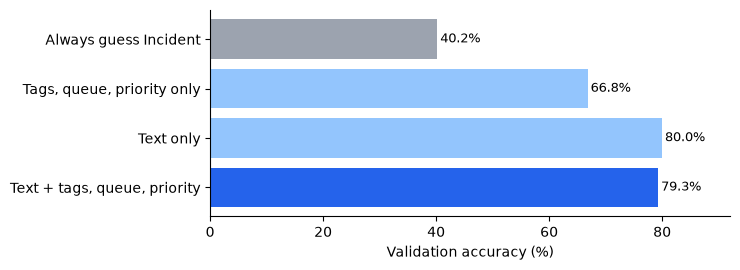

In [5]:
# Phase 7 (check 3): do tags, queue and priority add information beyond the text?
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder

meta = ["queue", "priority"] + [f"tag_{i}" for i in range(1, 9)]
dm = dev.join(df_raw[meta], on="raw_row")

def cramers_v(x, y):  # 0 = no link, 1 = perfect link (bias-corrected)
    t = pd.crosstab(x, y); n = t.values.sum(); r, k = t.shape
    phi2 = max(0, chi2_contingency(t, correction=False)[0] / n - (k - 1) * (r - 1) / (n - 1))
    rc, kc = r - (r - 1) ** 2 / (n - 1), k - (k - 1) ** 2 / (n - 1)
    return np.sqrt(phi2 / min(kc - 1, rc - 1))
v = pd.Series({c: cramers_v(dm[c].fillna("none").astype(str), dm["type"]) for c in meta}).sort_values(ascending=False)
display(v.round(3).rename("Cramer's V with type").to_frame())

tr, va = dm[dm["split"] == "train"], dm[dm["split"] == "validation"]
tf = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2)).fit(tr["text_clean"].fillna(""))
oh = OneHotEncoder(handle_unknown="ignore").fit(tr[meta].fillna("none").astype(str))
def feats(x, text, cols):
    parts = ([tf.transform(x["text_clean"].fillna(""))] if text else []) + ([oh.transform(x[meta].fillna("none").astype(str))] if cols else [])
    return sp.hstack(parts).tocsr()
acc = {"Always guess Incident": (va["type"] == "Incident").mean()}
for name, text, cols in [("Tags, queue, priority only", False, True), ("Text only", True, False), ("Text + tags, queue, priority", True, True)]:
    acc[name] = LogisticRegression(max_iter=2000).fit(feats(tr, text, cols), tr["type"]).score(feats(va, text, cols), va["type"])
fig, ax = plt.subplots(figsize=(7.5, 2.8))
ax.barh(list(acc)[::-1], [a * 100 for a in acc.values()][::-1], color=["#2563eb", "#93c5fd", "#93c5fd", "#9ca3af"])
for y, a in enumerate(list(acc.values())[::-1]):
    ax.text(a * 100 + 0.5, y, f"{a:.1%}", va="center", fontsize=9)
ax.set_xlim(0, 92); ax.set_xlabel("Validation accuracy (%)"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### Result
| Check | Finding |
|---|---|
| Reworded copies | 98.7% of tickets match their family's label. Only 59 of 3,692 families conflict (1.6%). |
| Similar tickets | When the nearest ticket from another family is 0.5 to 0.7 similar, 85.9% share the label. No two families are 0.7 or more similar, because families already group the near-copies. |
| Other columns | Tags link to the type (Cramer's V up to 0.48). They add nothing to the text: 79.3% with them, 80.0% without. |

**Conclusion**
- Label noise is **not** the cause of the ~80% ceiling. The labels are consistent.
- The other columns carry no extra signal. The text already holds it.
- What is left: the text alone may not decide Incident vs Problem. This is a likely explanation, not a proven one.
- The text-only model here is a quick check with its own settings. It is not the frozen baseline.
- The test set is open, so a new feature set could not get an honest test score now.